In [1]:
import sys 
import os

sys.path.insert(0, os.path.abspath('C:/Users/dagic/OneDrive/Documents/KAIM/Week_4/credit-risk-model/src'))

print('Path set. Python will now look in:', os.path.abspath('C:/Users/dagic/OneDrive/Documents/KAIM/Week_4/credit-risk-model/src'))

Path set. Python will now look in: C:\Users\dagic\OneDrive\Documents\KAIM\Week_4\credit-risk-model\src


In [2]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


sys.path.append(os.path.abspath("../"))

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

plt.rcParams["font.size"] = 12

In [3]:
from pathlib import Path
from src.data_processing import (
    load_processed_data,
    load_raw_data,
    cap_outliers,
    engineer_features,
    split_data,
    scale_features,
    encode_woe,
    CATEGORICAL_COLS,
)

processed_path = Path("../data/processed/data_with_proxy_target.csv")
if processed_path.exists():
    df = load_processed_data(str(processed_path))
else:
    raw_data_path = "../data/raw/german.csv"
    df = load_raw_data(raw_data_path)
    df = cap_outliers(df, cols=["credit_amount", "age"])
    df = engineer_features(df)
    print("Processed file not found; preprocessing raw data on the fly.")
df.head()


2026-06-05 12:16:25,152 [INFO] Loading processed data from: ..\data\processed\data_with_proxy_target.csv


,TransactionId,BatchId,AccountId,SubscriptionId,CustomerId,CurrencyCode,CountryCode,ProviderId,ProductId,ProductCategory,...,Transaction_Count,Std_Trans_Amount,TransactionHour,TransactionDay,TransactionMonth,TransactionYear,DayofWeek,IsWeekend,IsReversal,is_high_risk
0,78150,46980,2490,3535,2584,0,0.0,5,1,0,...,-0.311831,-0.167016,-2.155530,-0.100739,0.848684,-0.994246,-0.006389,-0.510703,-0.815149,0
1,75821,31755,3219,2366,2584,0,0.0,3,19,2,...,-0.311831,-0.167016,-2.155530,-0.100739,0.848684,-0.994246,-0.006389,-0.510703,1.226769,0
2,39888,60272,2713,996,2806,0,0.0,5,0,0,...,-0.444993,-0.201209,-2.155530,-0.100739,0.848684,-0.994246,-0.006389,-0.510703,-0.815149,1
3,48738,1797,3351,974,3733,0,0.0,0,11,8,...,-0.404020,-0.008243,-1.949214,-0.100739,0.848684,-0.994246,-0.006389,-0.510703,-0.815149,0
4,41364,48941,3219,2366,3733,0,0.0,3,19,2,...,-0.404020,-0.008243,-1.949214,-0.100739,0.848684,-0.994246,-0.006389,-0.510703,1.226769,0


In [4]:
df_woe, woe_maps = encode_woe(df, CATEGORICAL_COLS)
woe_cols = [f"{c}_woe" for c in CATEGORICAL_COLS if f"{c}_woe" in df_woe.columns]
all_features = [
    "Amount",
    "Value",
    "PricingStrategy"
] + woe_cols

df_model_data = df_woe[all_features + ["is_high_risk"]].dropna()
X_train, X_val, X_test, y_train, y_val, y_test = split_data(df_model_data, target="is_high_risk")
num_cols = ["Amount", "Value", "PricingStrategy"]
X_train, X_val, X_test, scaler = scale_features(X_train, X_val, X_test, num_cols=num_cols)


2026-06-05 12:16:25,795 [WARNING] Falling back to custom WoE encoding due to error
2026-06-05 12:17:01,634 [INFO] Train: 66962 | Val: 9567 | Test: 19133


In [5]:
import importlib
import train
importlib.reload(train)
from train import train_logistic_regression, train_random_forest, train_xgboost, evaluate_model

lr_model = train_logistic_regression(X_train, y_train)
rf_model = train_random_forest(X_train, y_train)
xgb_model = train_xgboost(X_train, y_train)

2026-06-05 12:17:04,675 [INFO] Training Logistic Regression...
2026-06-05 12:17:20,316 [INFO] Best LR params: {'C': 0.1, 'max_iter': 1000, 'solver': 'lbfgs'} | CV AUC: 0.9611
2026-06-05 12:17:20,321 [INFO] Training Random Forest...
2026-06-05 12:18:23,839 [INFO] Best RF params: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200} | CV AUC: 0.9758
2026-06-05 12:18:23,842 [INFO] Training XGBoost...
2026-06-05 12:18:33,836 [INFO] Best XGB params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200} | CV AUC: 0.9785


In [6]:
val_results = []
for name, model in [
    ("Logistic Regression", lr_model),
    ("Random Forest", rf_model),
    ("XGBoost", xgb_model),
]:
    metrics = evaluate_model(model, X_val, y_val, split_name=f"{name} [Val]")
    metrics["model"] = name
    val_results.append(metrics)

val_df = pd.DataFrame(val_results).set_index("model")[['accuracy', 'precision', 'recall', 'f1', 'roc_auc']]
val_df

best_model_name = val_df['roc_auc'].idxmax()
best_models = {
    'Logistic Regression': lr_model,
    'Random Forest': rf_model,
    'XGBoost': xgb_model,
}
best_model = best_models[best_model_name]
print(f"Best model by validation ROC-AUC: {best_model_name}")


2026-06-05 12:18:34,004 [INFO] 
Logistic Regression [Val] Results
2026-06-05 12:18:34,010 [INFO]   accuracy    : 0.8810
2026-06-05 12:18:34,012 [INFO]   precision   : 0.4634
2026-06-05 12:18:34,014 [INFO]   recall      : 0.9165
2026-06-05 12:18:34,016 [INFO]   f1          : 0.6155
2026-06-05 12:18:34,018 [INFO]   roc_auc     : 0.9634
2026-06-05 12:18:34,060 [INFO] 
              precision    recall  f1-score   support

 Good Credit       0.99      0.88      0.93      8573
     Default       0.46      0.92      0.62       994

    accuracy                           0.88      9567
   macro avg       0.73      0.90      0.77      9567
weighted avg       0.93      0.88      0.90      9567

2026-06-05 12:18:35,306 [INFO] 
Random Forest [Val] Results
2026-06-05 12:18:35,308 [INFO]   accuracy    : 0.9368
2026-06-05 12:18:35,309 [INFO]   precision   : 0.6382
2026-06-05 12:18:35,310 [INFO]   recall      : 0.9034
2026-06-05 12:18:35,314 [INFO]   f1          : 0.7480
2026-06-05 12:18:35,316 [INFO

Best model by validation ROC-AUC: XGBoost


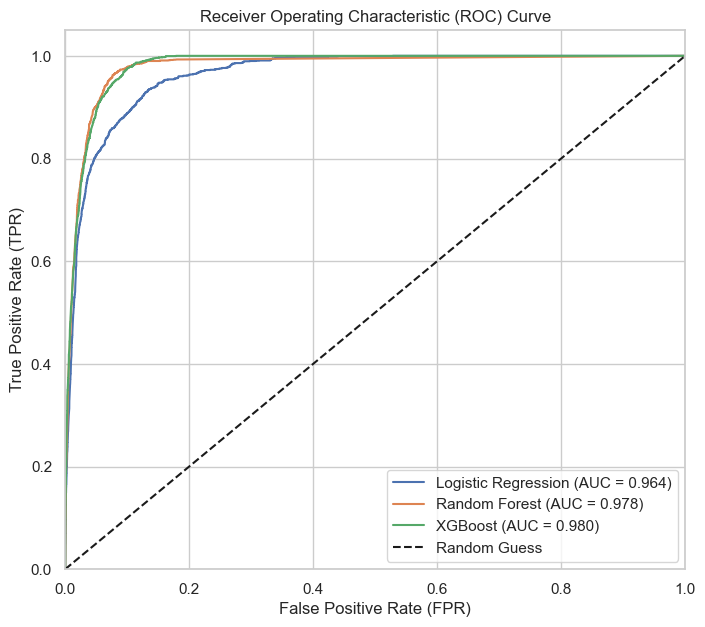

In [7]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(8, 7))

for name, model in [("Logistic Regression", lr_model), ("Random Forest", rf_model), ("XGBoost", xgb_model)]:
    probs = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, probs)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], "k--", label="Random Guess")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend(loc="lower right")
plt.show()


Model Interpretability

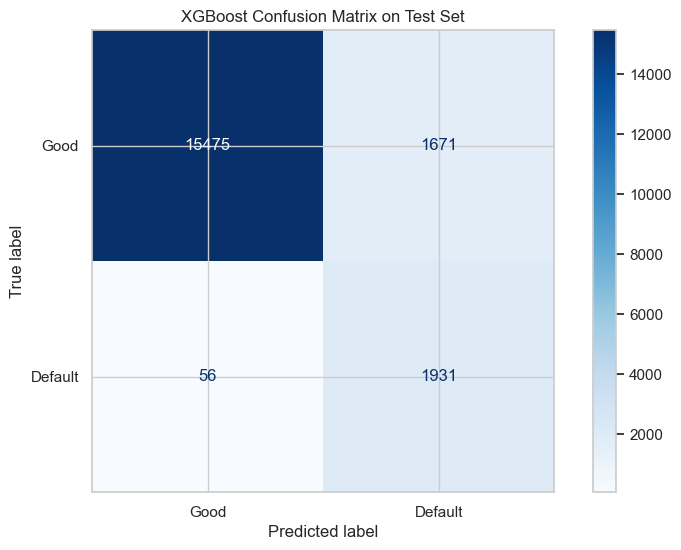

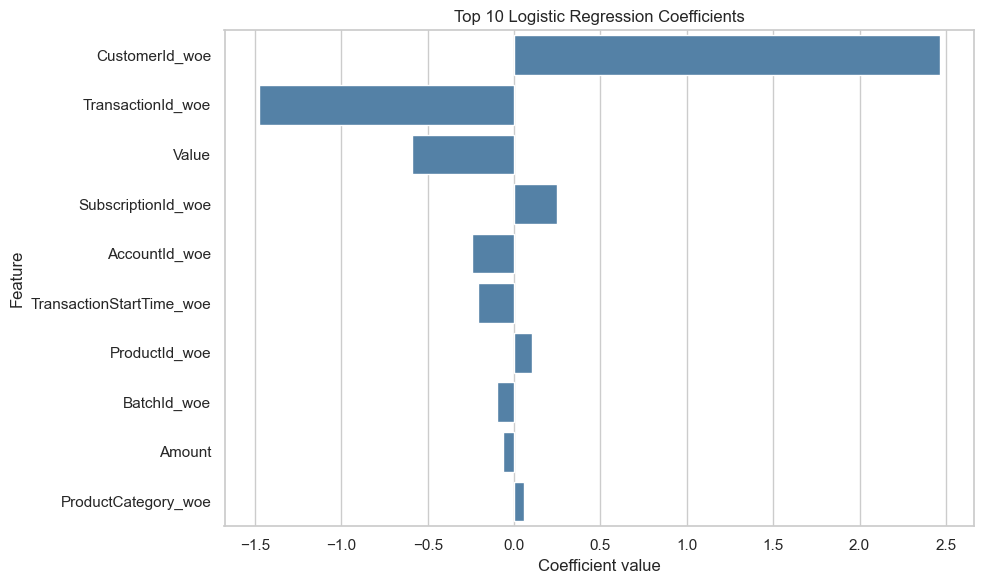

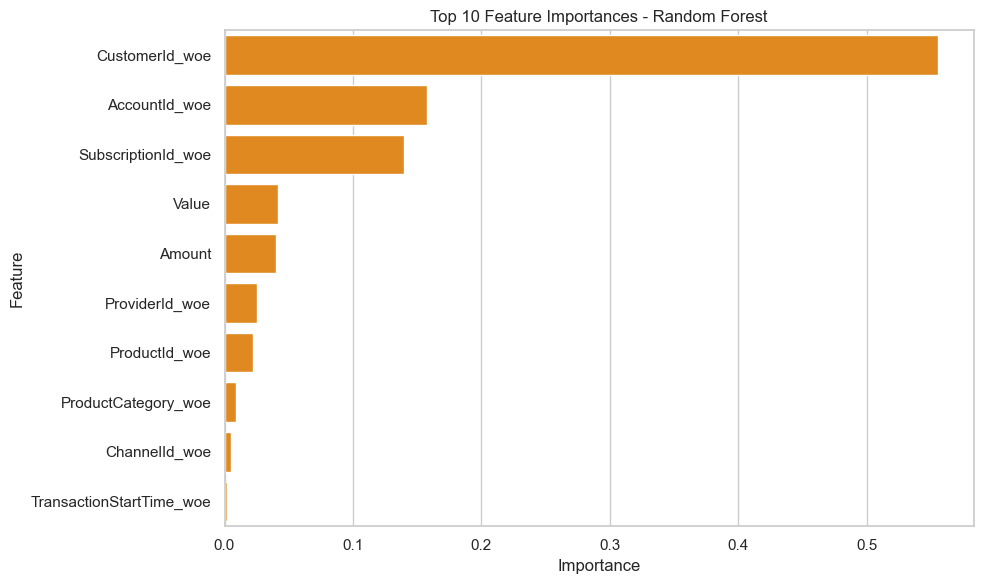

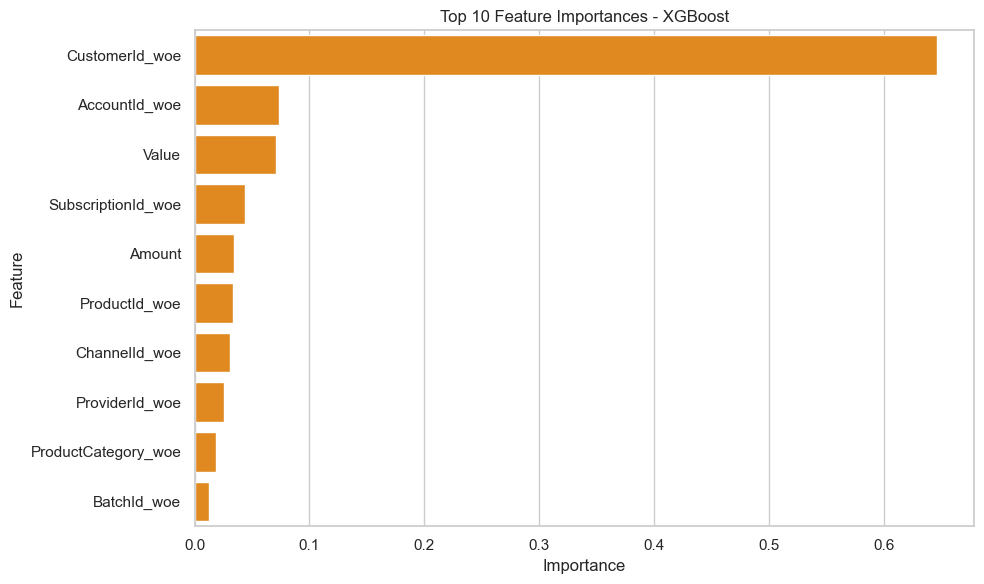

c:\Users\dagic\OneDrive\Documents\KAIM\Week_4\credit-risk-model\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


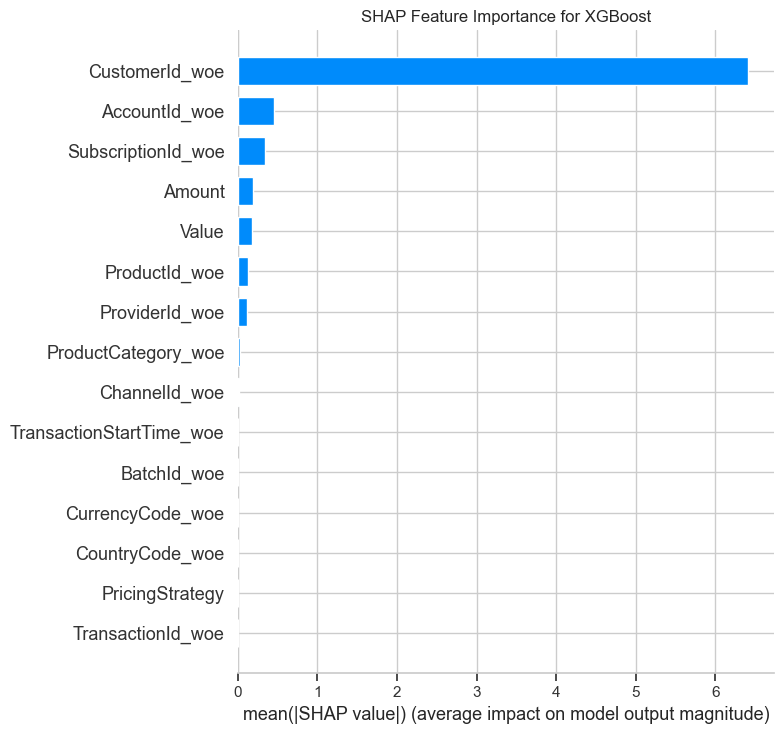

In [8]:
from sklearn.metrics import ConfusionMatrixDisplay

# Confusion matrix for the best validation model on the test set
y_test_pred = best_model.predict(X_test)
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred,
    display_labels=['Good', 'Default'],
    cmap='Blues',
)
plt.title(f"{best_model_name} Confusion Matrix on Test Set")
plt.show()

# Logistic Regression coefficients
lr_coefs = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': lr_model.coef_[0],
})
lr_coefs['abs_coef'] = lr_coefs['coefficient'].abs()
lr_coefs = lr_coefs.sort_values('abs_coef', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(data=lr_coefs, x='coefficient', y='feature', color='steelblue')
plt.title('Top 10 Logistic Regression Coefficients')
plt.xlabel('Coefficient value')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# Tree-based feature importances
for model_name, model in [('Random Forest', rf_model), ('XGBoost', xgb_model)]:
    if hasattr(model, 'feature_importances_'):
        imp = pd.DataFrame({
            'feature': X_train.columns,
            'importance': model.feature_importances_,
        }).sort_values('importance', ascending=False).head(10)
        plt.figure(figsize=(10, 6))
        sns.barplot(data=imp, x='importance', y='feature', color='darkorange')
        plt.title(f'Top 10 Feature Importances - {model_name}')
        plt.xlabel('Importance')
        plt.ylabel('Feature')
        plt.tight_layout()
        plt.show()

# SHAP explanation for the XGBoost model
try:
    import shap
    explainer = shap.TreeExplainer(xgb_model)
    shap_values = explainer.shap_values(X_test)
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values, X_test, plot_type='bar', show=False)
    plt.title('SHAP Feature Importance for XGBoost')
    plt.tight_layout()
    plt.show()
except Exception as e:
    print('SHAP is not available or could not run:', e)


## Portfolio-Level Expected Loss & Risk Tiering

We now use XGBoost-based predicted default probabilities to quantify portfolio expected loss and assign risk tiers.


In [9]:
xgb_test_probs = xgb_model.predict_proba(X_test)[:, 1]
test_summary = pd.DataFrame({
    "Actual_Default": y_test.values,
    "PD": xgb_test_probs,
    "EAD": df_woe.loc[X_test.index, "Amount"].values,
})

test_summary["LGD"] = 0.45
test_summary["Expected_Loss"] = test_summary["PD"] * test_summary["LGD"] * test_summary["EAD"]

def get_tier(p):
    if p < 0.20:
        return "LOW"
    if p < 0.40:
        return "MEDIUM-LOW"
    if p < 0.60:
        return "MEDIUM-HIGH"
    return "HIGH"

test_summary["Risk_Tier"] = test_summary["PD"].apply(get_tier)
test_summary.head(10)


,Actual_Default,PD,EAD,LGD,Expected_Loss,Risk_Tier
0,0,0.947270,1.105942,0.45,4.714313e-01,HIGH
1,0,0.000022,1.752200,0.45,1.764061e-05,LOW
2,0,0.418457,-0.529169,0.45,-9.964540e-02,MEDIUM-HIGH
3,0,0.696857,-0.463765,0.45,-1.454299e-01,HIGH
4,0,0.000036,-1.798326,0.45,-2.930515e-05,LOW
5,0,0.000037,-0.560314,0.45,-9.311576e-06,LOW
6,0,0.000067,-0.457536,0.45,-1.377734e-05,LOW
7,0,0.000012,0.171593,0.45,9.394432e-07,LOW
8,0,0.000040,-0.480894,0.45,-8.590665e-06,LOW
9,1,0.861402,-0.139857,0.45,-5.421284e-02,HIGH


In [10]:
portfolio_el = test_summary["Expected_Loss"].sum()
portfolio_ead = test_summary["EAD"].sum()
print(f"Total Portfolio EAD: {portfolio_ead:,.2f} DM")
print(f"Total Expected Portfolio Loss (EL): {portfolio_el:,.2f} DM ({portfolio_el/portfolio_ead*100:.2f}%)")
print(test_summary["Risk_Tier"].value_counts())


Total Portfolio EAD: 265.57 DM
Total Expected Portfolio Loss (EL): 106.23 DM (40.00%)
Risk_Tier
LOW            14392
HIGH            3187
MEDIUM-HIGH      787
MEDIUM-LOW       767
Name: count, dtype: int64


In [12]:
import os
import xgboost as xgb
import joblib
os.makedirs("models", exist_ok=True)
joblib.dump(model, "models/credit_risk_xgb.pkl")

['models/credit_risk_xgb.pkl']